In [174]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [175]:
K_REFINED = None # None = all refinements; set e.g. 1 to truncate Bayesian after k-th refinement

In [176]:
LBFGS_SWEEP = 'convergence_w5_lbfgs/04_25'
BAYESIAN_SWEEP = 'convergence_w5_bayesian/04_25'

In [177]:
BASE = '../examples/comparisons/combined_boundary_DIIID'

def load_run(run_dir):
    results_path = os.path.join(run_dir, 'results.json')
    if not os.path.exists(results_path):
        return None
    with open(results_path) as f:
        raw = json.load(f)
    s = raw['optimization_settings']
    method_name = list(raw['methods'].keys())[0]
    d = raw['methods'][method_name]
    d['optimization_settings'] = s
    d['method'] = method_name
    d['source'] = 'results'
    return d

def discover_runs(base):
    runs = []
    for sweep in sorted(os.listdir(base)):
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

8 runs found
  convergence_w5_b_temp/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-01  best=3.9338e-01  evals=553  stop=all refinements completed
  convergence_w5_b_temp/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-02  best=8.1188e-01  evals=493  stop=all refinements completed
  convergence_w5_b_temp/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-03  best=9.0385e-01  evals=514  stop=all refinements completed
  convergence_w5_b_temp/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-04  best=7.6914e-01  evals=560  stop=all refinements completed
  convergence_w5_l_temp/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=3.9263e-02  evals=2289  stop=converged
  convergence_w5_l_temp/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=1.9261e-02  eval

In [178]:
def discover_runs(base):
    runs = []
    for sweep in [LBFGS_SWEEP, BAYESIAN_SWEEP]:
        sweep_dir = os.path.join(base, sweep)
        if not os.path.isdir(sweep_dir):
            print(f"not found: {sweep_dir}")
            continue
        for config in sorted(os.listdir(sweep_dir)):
            config_dir = os.path.join(sweep_dir, config)
            if not os.path.isdir(config_dir):
                continue
            for run in sorted(os.listdir(config_dir)):
                run_dir = os.path.join(config_dir, run)
                if not os.path.isdir(run_dir):
                    continue
                d = load_run(run_dir)
                if d is None:
                    continue
                s = d.get('optimization_settings', {})
                runs.append({
                    'sweep': sweep,
                    'config': config,
                    'run': run,
                    'run_dir': run_dir,
                    'source': d['source'],
                    'method': d.get('method', '?'),
                    'weight_fb': s.get('weight_fb', float('nan')),
                    'alpha': s.get('alpha', float('nan')),
                    'num_coils': s.get('num_coils', '?'),
                    'n_evals': d.get('n_evals', float('nan')),
                    'best_cost': d.get('best_cost', float('nan')),
                    'best_flux_err': d.get('best_flux_err', float('nan')),
                    'best_fb_cost': d.get('best_fb_cost', float('nan')),
                    'fb_failures': d.get('fb_failures', float('nan')),
                    'elapsed': d.get('elapsed', d.get('time', float('nan'))),
                    'stopping': d.get('stopping', '?'),
                    'data': d,
                })
    return runs

runs = discover_runs(BASE)
print(f"{len(runs)} runs found")
for r in runs:
    print(f"  {r['sweep']}/{r['config']}/{r['run']}  method={r['method']}  weight_fb={r['weight_fb']:.0e}  best={r['best_cost']:.4e}  evals={r['n_evals']}  stop={r['stopping']}")

8 runs found
  convergence_w5_lbfgs/04_25/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-01  best=3.9263e-02  evals=2289  stop=converged
  convergence_w5_lbfgs/04_25/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-02  best=1.9261e-02  evals=1701  stop=converged
  convergence_w5_lbfgs/04_25/alpha:0.75,weight:1e-03,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-03  best=2.1638e-02  evals=1897  stop=converged
  convergence_w5_lbfgs/04_25/alpha:0.75,weight:1e-04,lambda:1e-06,coils:3/run_01  method=Multi-start L-BFGS  weight_fb=1e-04  best=1.9580e-02  evals=1771  stop=converged
  convergence_w5_bayesian/04_25/alpha:0.75,weight:1e-01,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-01  best=3.9338e-01  evals=553  stop=all refinements completed
  convergence_w5_bayesian/04_25/alpha:0.75,weight:1e-02,lambda:1e-06,coils:3/run_01  method=Bayesian  weight_fb=1e-02  best=8.118

In [ ]:
rows = []
for r in runs:
    d = r['data']
    if 'cost_history' not in d:
        continue
    alpha = d.get('optimization_settings', {}).get('alpha', 0.75)
    total = np.array(d['cost_history'], dtype=float)
    flux_h = np.array([x if x is not None else np.nan for x in d.get('flux_err_history', [])], dtype=float)
    fb_h = np.array([x if x is not None else np.nan for x in d.get('fb_cost_history', [])], dtype=float)

    truncated = False
    if r['method'] == 'Bayesian' and K_REFINED is not None:
        n_bay = d.get('n_bayesian_evals', len(total))
        ref_evals = d.get('refinement_evals', [])
        trunc = n_bay + sum(ref_evals[:min(K_REFINED, len(ref_evals))])
        if trunc > 0:
            total = total[:trunc]
            flux_h = flux_h[:trunc]
            fb_h = fb_h[:trunc]
            truncated = True
        t_bay = d.get('time_bayesian_phase', float('nan'))
        ref_times = d.get('refinement_times', [])
        elapsed_h = (t_bay + sum(ref_times[:min(K_REFINED, len(ref_times))])) / 3600
    else:
        elapsed_h = r['elapsed'] / 3600

    if len(total) == 0:
        continue

    if truncated:
        idx = int(np.nanargmin(total))
        best_flux = float(flux_h[idx]) if idx < len(flux_h) and np.isfinite(flux_h[idx]) else float(np.nanmin(flux_h))
        best_fb = float(fb_h[idx]) if idx < len(fb_h) and np.isfinite(fb_h[idx]) else float(np.nanmin(fb_h))
    else:
        best_flux = float(d.get('best_flux_err', float('nan')))
        best_fb = float(d.get('best_fb_cost', float('nan')))

    rows.append({
        'sweep': r['sweep'],
        'method': r['method'],
        'weight_fb': r['weight_fb'],
        'num_coils': r['num_coils'],
        'alpha': alpha,
        'best_cost_stored': float(np.nanmin(total)),
        'best_flux_err': best_flux,
        'best_fb_cost': best_fb,
        'init_fixed': float(d.get('initial_fixed_cost', float('nan'))),
        'init_fb': float(d.get('initial_fb_cost', float('nan'))),
        'fb_failures': r['fb_failures'],
        'n_evals': len(total),
        'elapsed_h': elapsed_h,
        'stopping': r['stopping'],
    })

df = pd.DataFrame(rows)

# per weight_fb pair: norm = max(init_lbfgs, init_bayesian)
norm_df = df.groupby('weight_fb')[['init_fixed', 'init_fb']].max()
norm_df.columns = ['norm_fixed', 'norm_fb']
df = df.join(norm_df, on='weight_fb')

df['best_cost_shared'] = (
    (1 - df['alpha']) * df['best_flux_err'] / df['norm_fixed'] +
    df['alpha'] * df['best_fb_cost'] / df['norm_fb']
)

df = df.sort_values(['weight_fb', 'method'])
pd.set_option('display.float_format', '{:.4e}'.format)
df

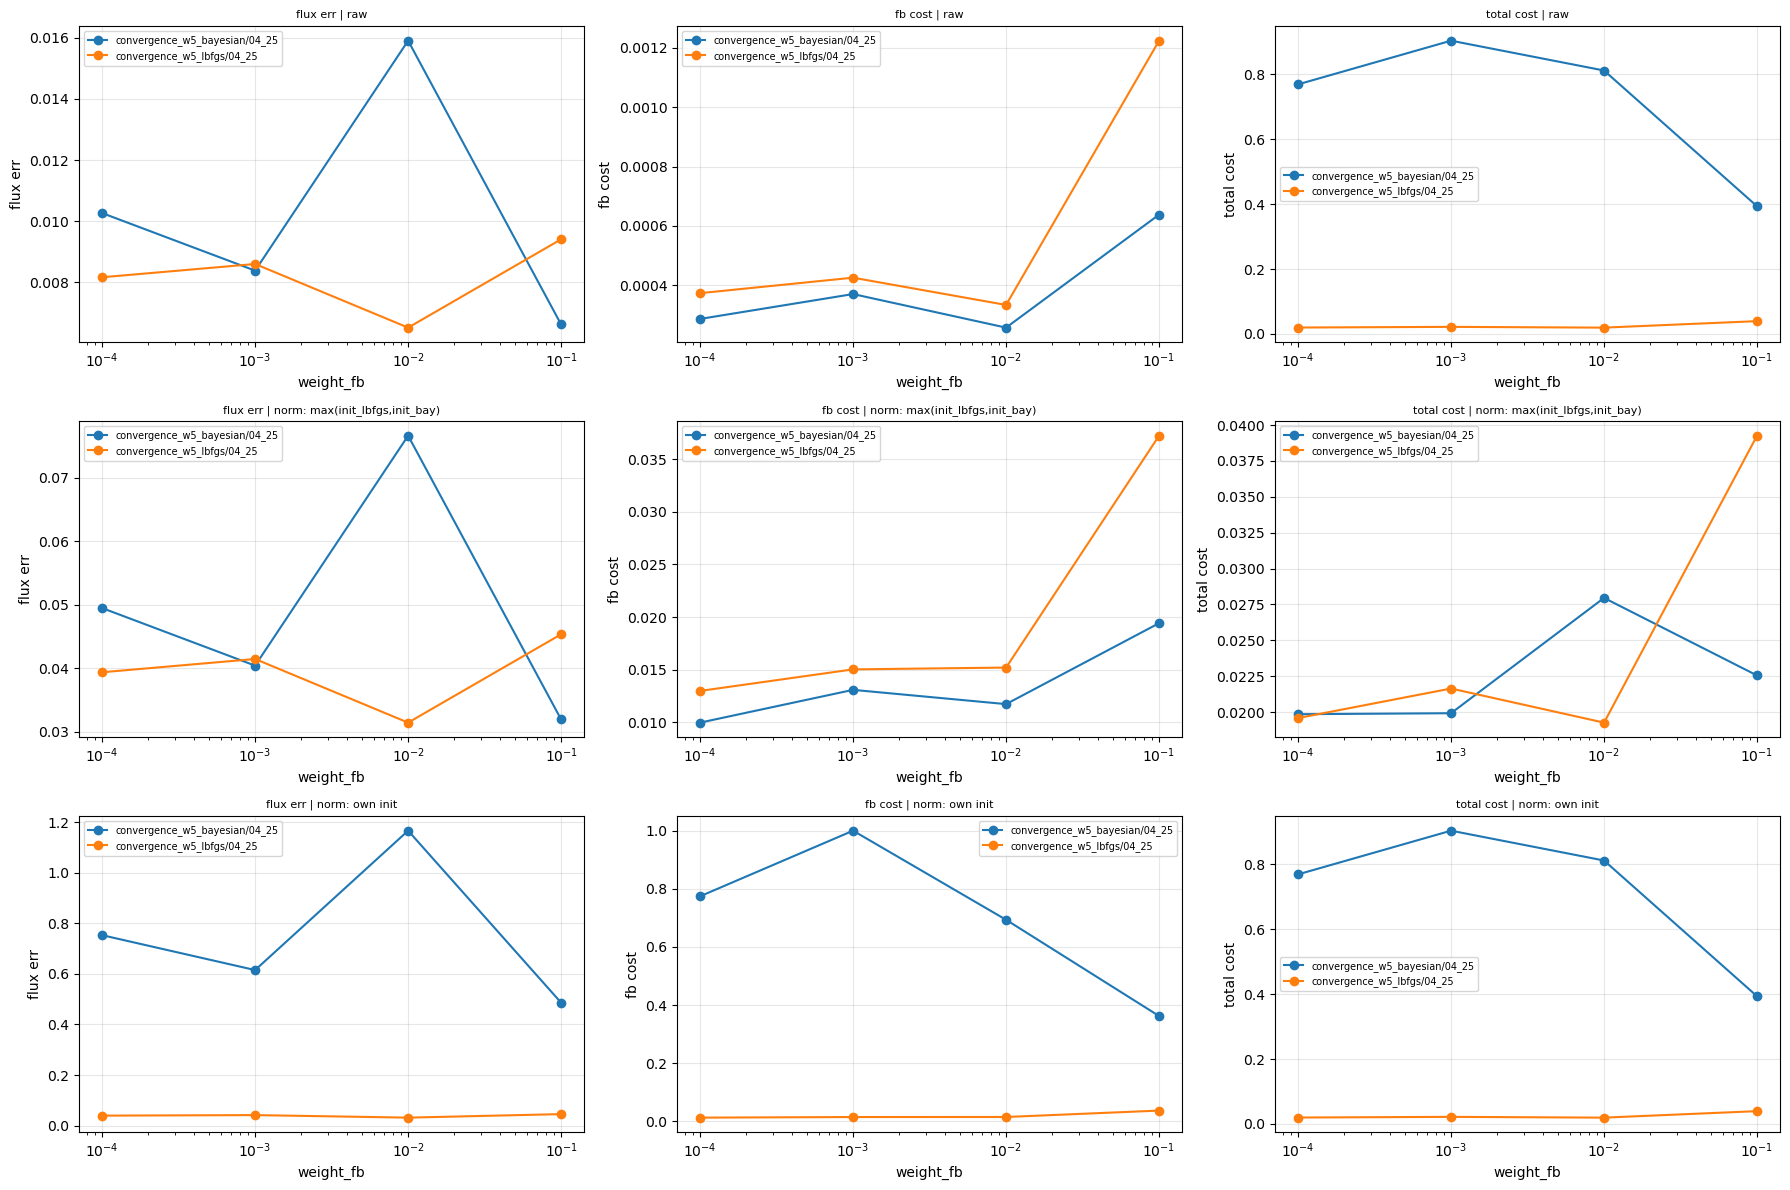

In [180]:
df['flux_shared'] = df['best_flux_err'] / df['norm_fixed']
df['fb_shared']   = df['best_fb_cost']  / df['norm_fb']
df['flux_own']    = df['best_flux_err'] / df['init_fixed']
df['fb_own']      = df['best_fb_cost']  / df['init_fb']
df['total_own']   = (1 - df['alpha']) * df['flux_own'] + df['alpha'] * df['fb_own']

sweeps = df['sweep'].unique()

rows_cfg = [
    ('raw',                           'best_flux_err', 'best_fb_cost', 'best_cost_stored'),
    ('norm: max(init_lbfgs,init_bay)', 'flux_shared',  'fb_shared',   'best_cost_shared'),
    ('norm: own init',                'flux_own',      'fb_own',      'total_own'),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row, (row_label, flux_col, fb_col, total_col) in enumerate(rows_cfg):
    for col, (metric, ylabel) in enumerate([
        (flux_col,  'flux err'),
        (fb_col,    'fb cost'),
        (total_col, 'total cost'),
    ]):
        ax = axes[row][col]
        for sweep in sweeps:
            sub = df[df['sweep'] == sweep].sort_values('weight_fb')
            ax.plot(sub['weight_fb'], sub[metric], marker='o', label=sweep)
        ax.set_xscale('log')
        ax.set_xlabel('weight_fb')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{ylabel} | {row_label}', fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


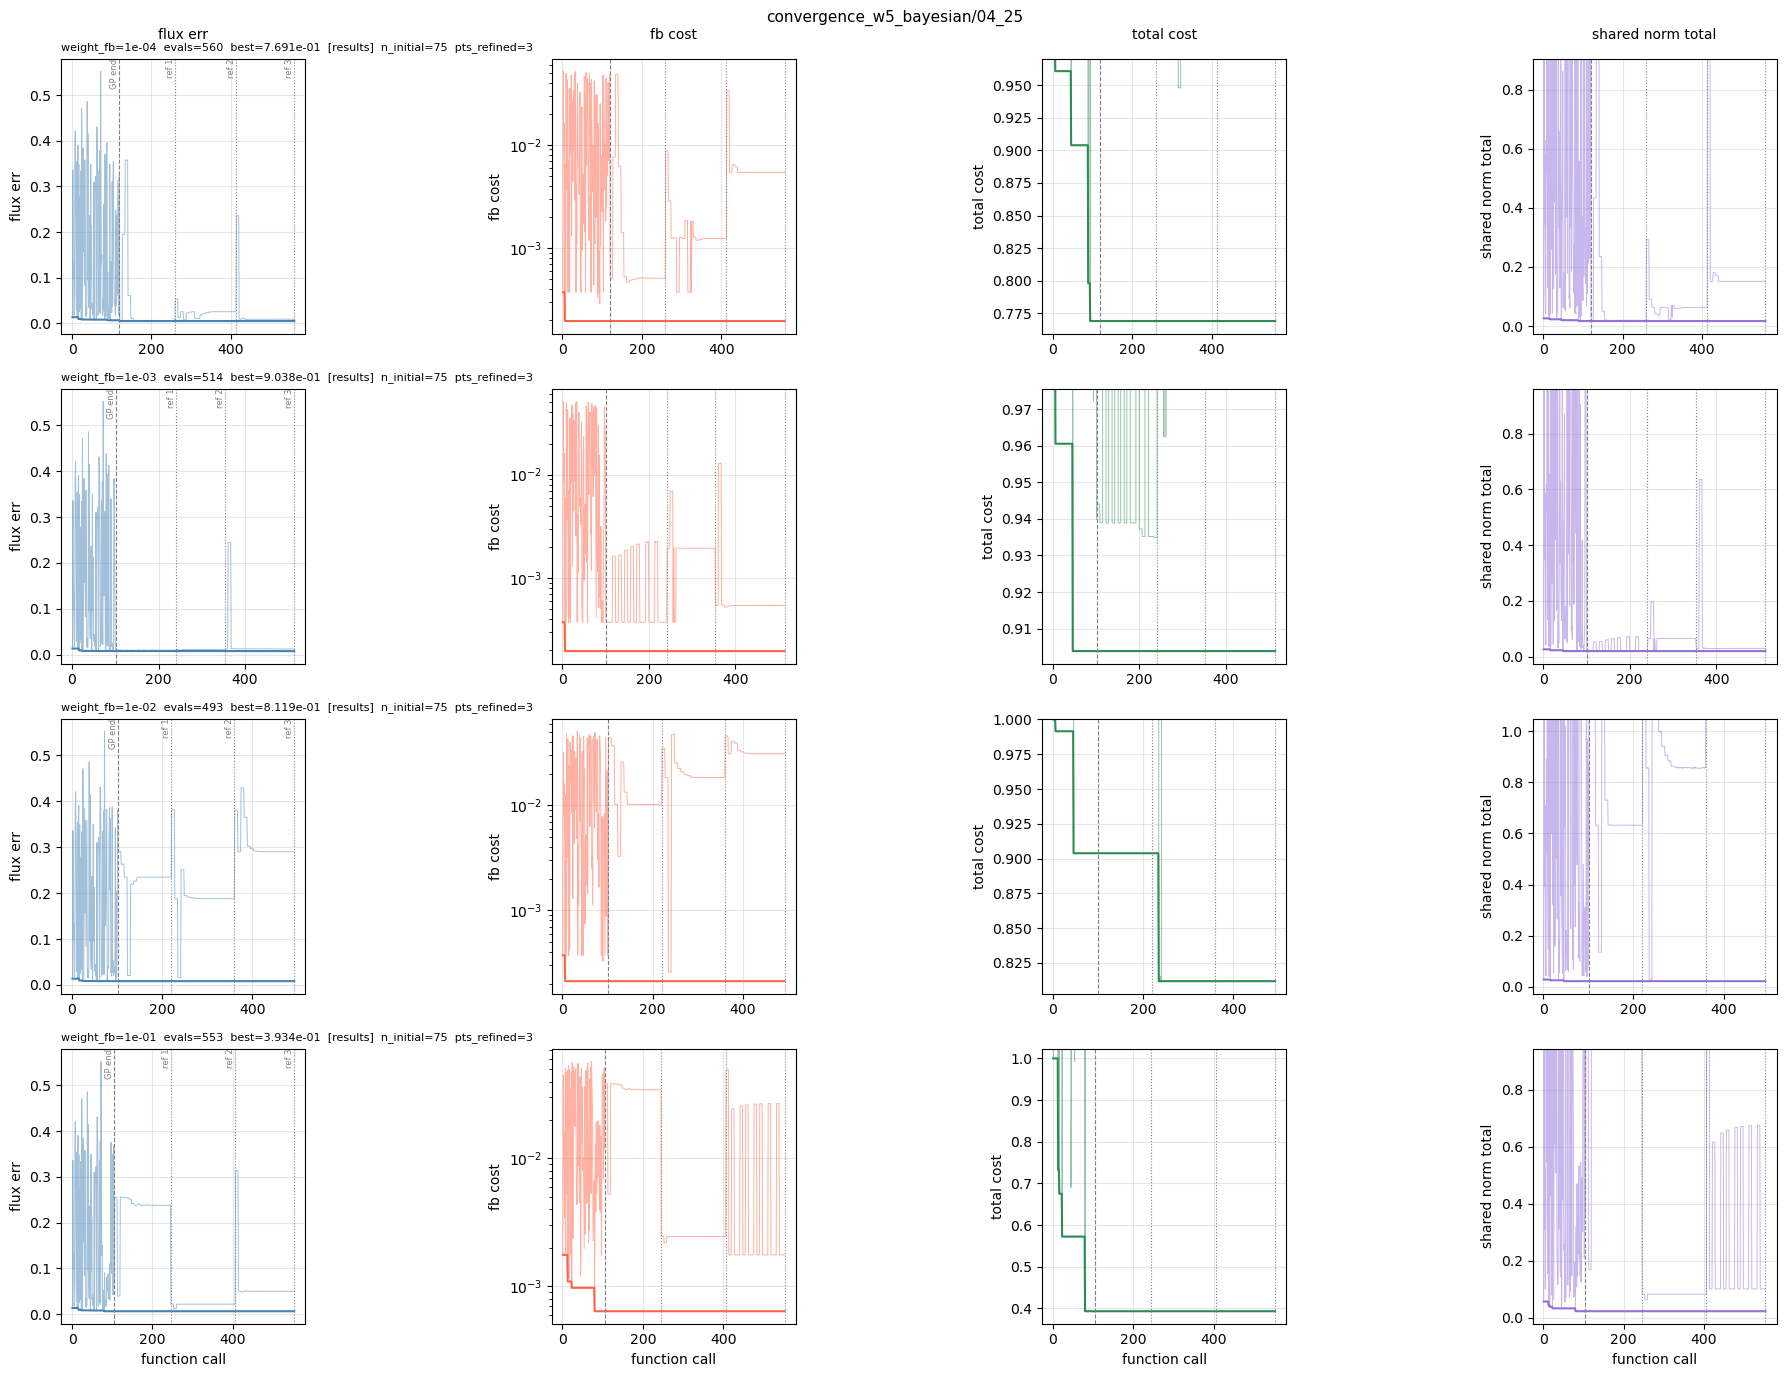

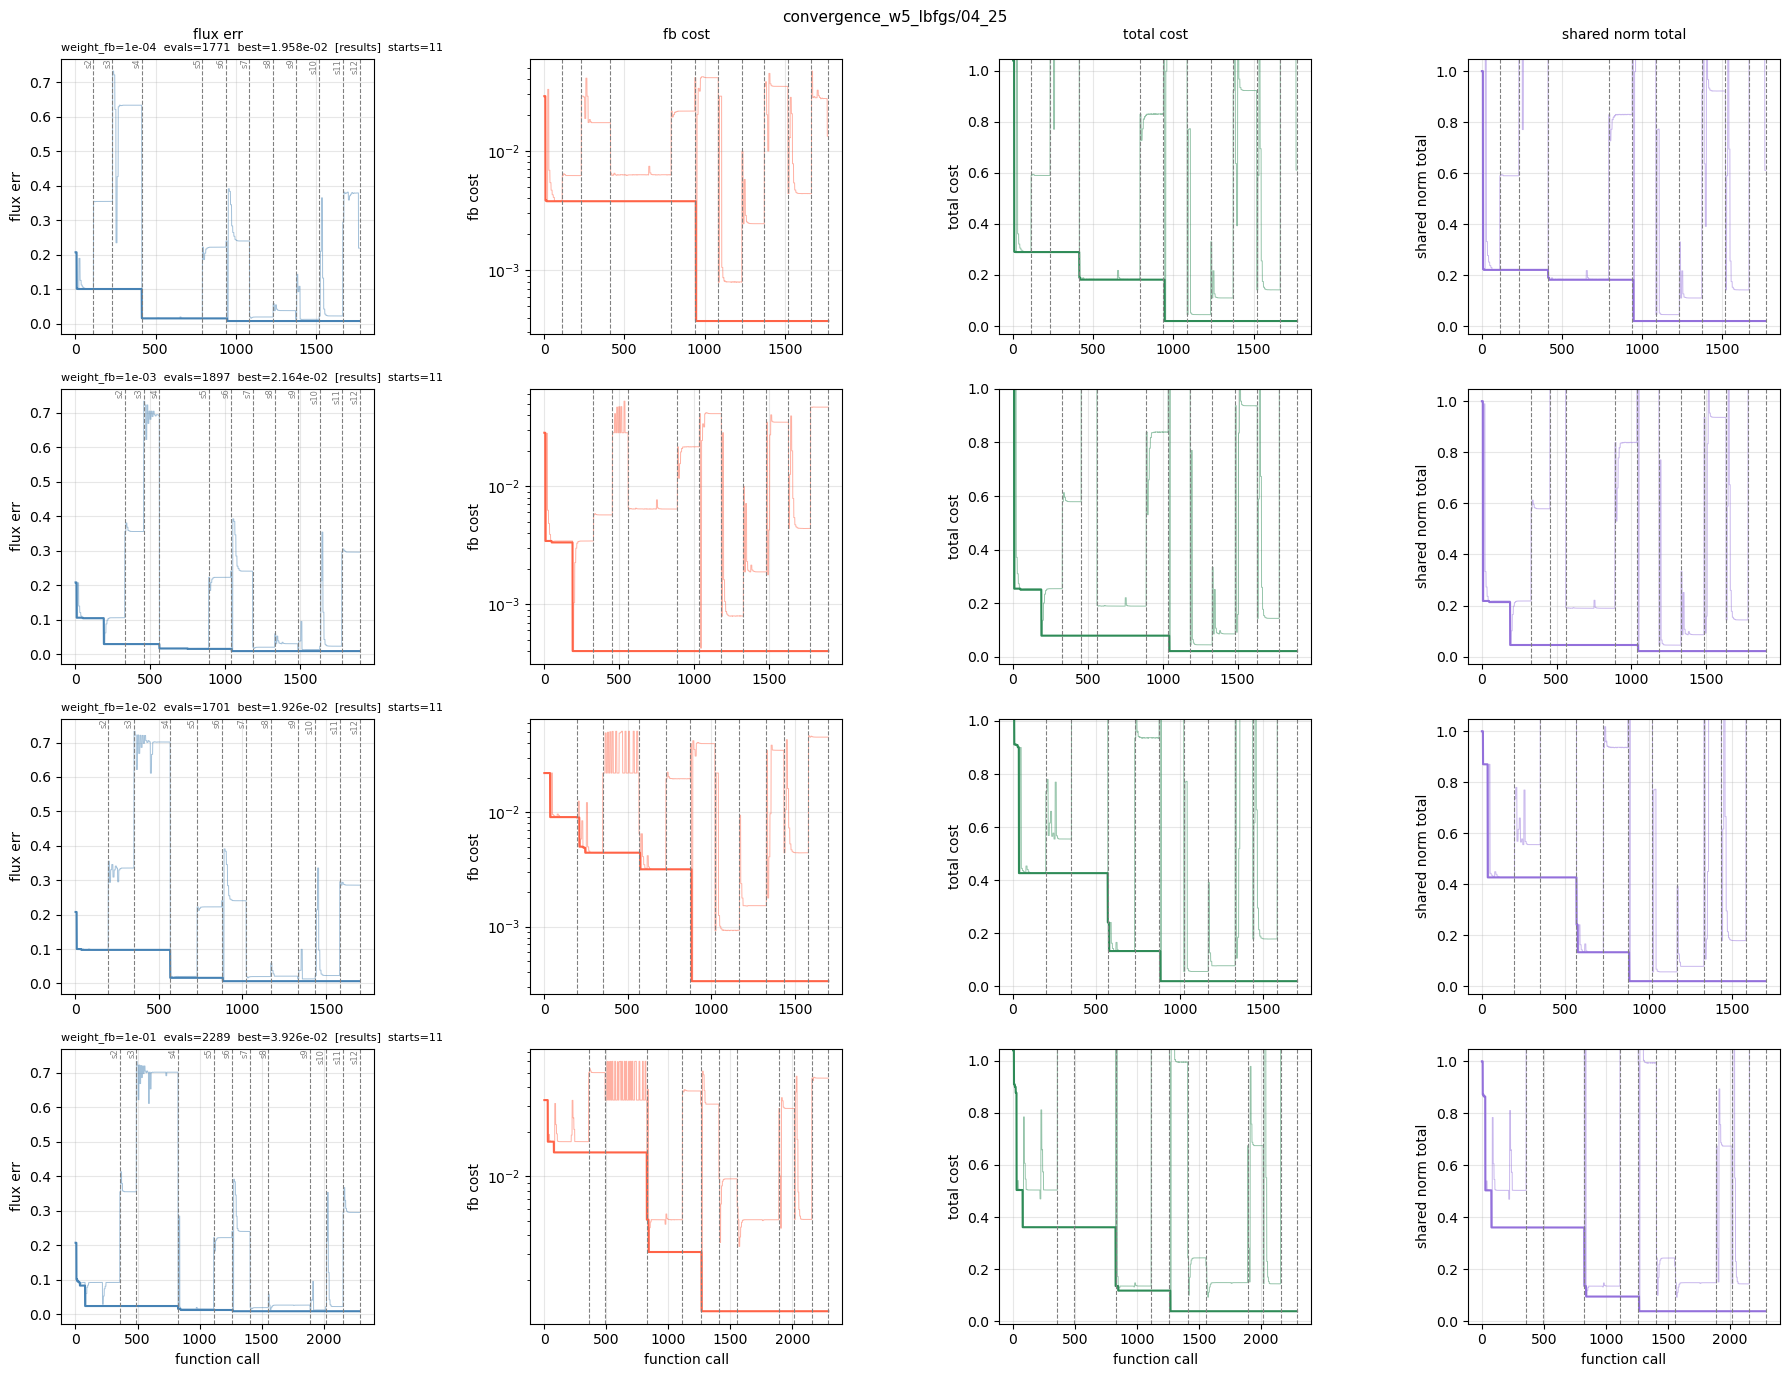

In [181]:
# --- filter ---
SHOW_SWEEPS = None   # None = all, or e.g. ['convergence_w5']
SHOW_WEIGHTS = None  # None = all, or e.g. [1e-2, 1e-4]
SHOW_COILS = None    # None = all, or e.g. [3, 4]
CLIP = 1          # values >= this are plotted but ignored for ylim
# --------------

filtered = [
    r for r in runs
    if (SHOW_SWEEPS is None or r['sweep'] in SHOW_SWEEPS)
    and (SHOW_WEIGHTS is None or any(abs(r['weight_fb'] - w) < 1e-12 for w in SHOW_WEIGHTS))
    and (SHOW_COILS is None or r['num_coils'] in SHOW_COILS)
]

norm_lookup = df.drop_duplicates('weight_fb').set_index('weight_fb')[['norm_fixed', 'norm_fb', 'alpha']]

COL_LABELS = ['flux err', 'fb cost', 'total cost', 'shared norm total']

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = [r for r in filtered if r['sweep'] == sweep]
    n = len(sweep_runs)
    fig, axes = plt.subplots(n, 4, figsize=(18, 3.5 * n), sharex=False, squeeze=False)
    fig.suptitle(sweep, fontsize=11)

    for col, label in enumerate(COL_LABELS):
        axes[0][col].set_title(label, fontsize=10, pad=14)

    for row, r in enumerate(sorted(sweep_runs, key=lambda x: x['weight_fb'])):
        d = r['data']
        total = np.array(d['cost_history'], dtype=float)
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []

        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            total, flux, fb = total[:trunc], flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cumulative = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cumulative += re
                phase_lines.append((f'ref {i+1}', cumulative, ':'))
            pts_label = k if K_REFINED is not None else d.get('pts_refined', '?')
            extra = f"  n_initial={d.get('n_initial','?')}  pts_refined={pts_label}"
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))
            extra = f"  starts={d.get('starts_completed','?')}"

        w = r['weight_fb']
        norm_fixed = norm_lookup.loc[w, 'norm_fixed']
        norm_fb = norm_lookup.loc[w, 'norm_fb']
        alpha = norm_lookup.loc[w, 'alpha']
        shared_total = (1 - alpha) * flux / norm_fixed + alpha * fb / norm_fb

        evals = np.arange(1, len(total) + 1)
        run_title = f"weight_fb={w:.0e}  evals={len(total)}  best={np.nanmin(total):.3e}  [{r['source']}]{extra}"

        for ax, y, color, ylabel in zip(
            axes[row],
            [flux, fb, total, shared_total],
            ['steelblue', 'tomato', 'seagreen', 'mediumpurple'],
            COL_LABELS,
        ):
            ax.plot(evals, y, lw=0.7, alpha=0.5, color=color)
            running_best = np.minimum.accumulate(np.where(np.isnan(y), np.inf, y))
            running_best[running_best == np.inf] = np.nan
            ax.plot(evals, running_best, lw=1.5, color=color)
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.3)
            if row == len(sweep_runs) - 1:
                ax.set_xlabel('function call')

            if ylabel == 'fb cost':
                ax.set_yscale('log')
            else:
                finite = y[np.isfinite(y) & (y < CLIP)]
                if len(finite):
                    pad = (finite.max() - finite.min()) * 0.05 or finite.min() * 0.05
                    ax.set_ylim(finite.min() - pad, finite.max() + pad)

            for lbl, x, ls in phase_lines:
                ax.axvline(x, color='gray', lw=0.8, ls=ls)
                if ax is axes[row][0]:
                    ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right',
                            va='top', rotation=90, color='gray')

        axes[row][0].annotate(run_title, xy=(0, 1), xycoords='axes fraction',
                              xytext=(0, 4), textcoords='offset points',
                              fontsize=8, va='bottom')

    plt.tight_layout()
    plt.show()


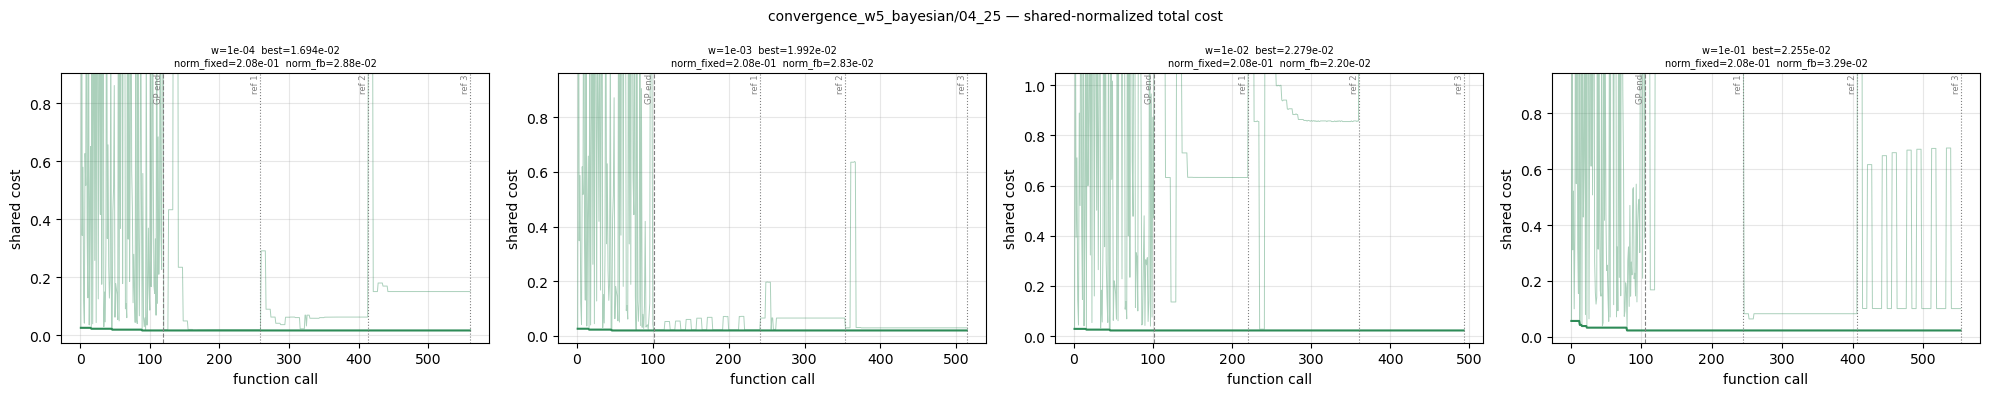

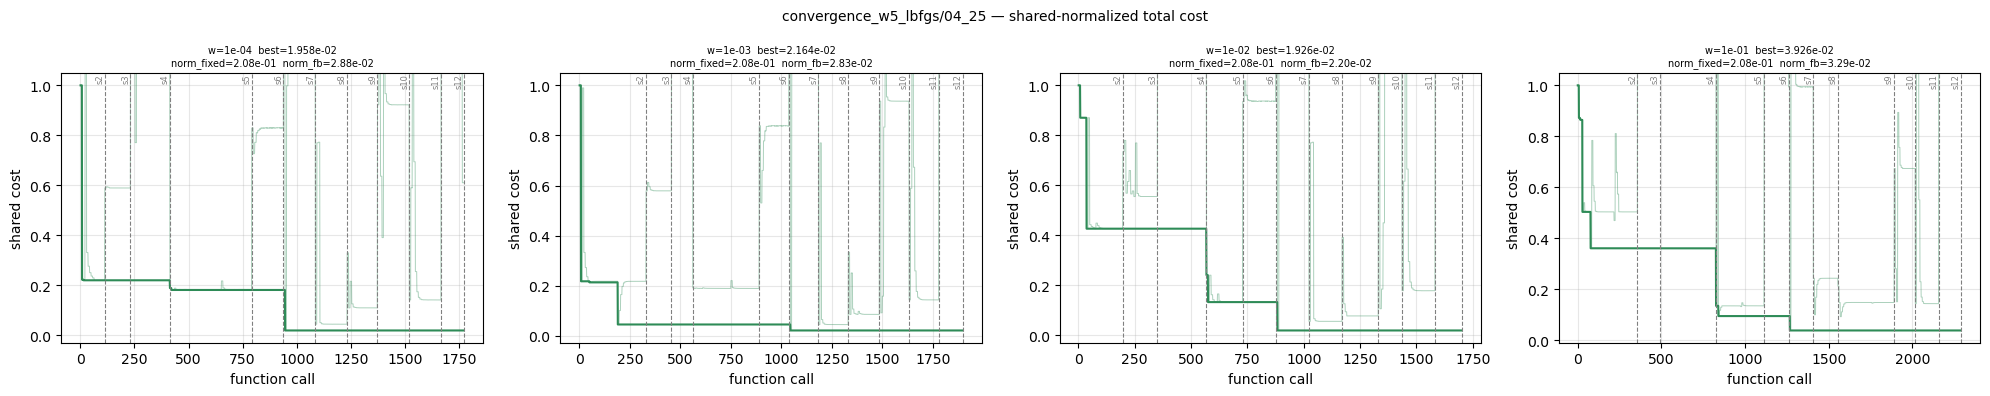

In [182]:
# shared-normalized total cost history (norm = max(init_lbfgs, init_bayesian) per weight_fb)
norm_lookup = df.drop_duplicates('weight_fb').set_index('weight_fb')[['norm_fixed', 'norm_fb', 'alpha']]
CLIP = 1

filtered = runs

for sweep in sorted(set(r['sweep'] for r in filtered)):
    sweep_runs = sorted([r for r in filtered if r['sweep'] == sweep], key=lambda x: x['weight_fb'])
    n = len(sweep_runs)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), squeeze=False)
    fig.suptitle(f"{sweep} — shared-normalized total cost", fontsize=10)

    for col, r in enumerate(sweep_runs):
        d = r['data']
        flux = np.array([x if x is not None else np.nan for x in d['flux_err_history']], dtype=float)
        fb = np.array([x if x is not None else np.nan for x in d['fb_cost_history']], dtype=float)

        phase_lines = []
        if r['method'] == 'Bayesian':
            n_bay = d.get('n_bayesian_evals', 0)
            ref_evals = d.get('refinement_evals', [])
            k = len(ref_evals) if K_REFINED is None else min(K_REFINED, len(ref_evals))
            trunc = n_bay + sum(ref_evals[:k])
            flux, fb = flux[:trunc], fb[:trunc]
            phase_lines.append(('GP end', n_bay, '--'))
            cum = n_bay
            for i, re in enumerate(ref_evals[:k]):
                cum += re
                phase_lines.append((f'ref {i+1}', cum, ':'))
        else:
            for i, x in enumerate(d.get('start_boundaries', [])):
                phase_lines.append((f's{i+2}', x, '--'))

        w = r['weight_fb']
        norm_fixed = norm_lookup.loc[w, 'norm_fixed']
        norm_fb = norm_lookup.loc[w, 'norm_fb']
        alpha = norm_lookup.loc[w, 'alpha']
        shared_total = (1 - alpha) * flux / norm_fixed + alpha * fb / norm_fb

        evals = np.arange(1, len(shared_total) + 1)
        ax = axes[0][col]
        ax.plot(evals, shared_total, lw=0.7, alpha=0.4, color='seagreen')
        rb = np.minimum.accumulate(np.where(np.isnan(shared_total), np.inf, shared_total))
        rb[rb == np.inf] = np.nan
        ax.plot(evals, rb, lw=1.5, color='seagreen')
        ax.set_ylabel('shared cost')
        ax.set_xlabel('function call')
        ax.grid(True, alpha=0.3)

        finite = shared_total[np.isfinite(shared_total) & (shared_total < CLIP)]
        if len(finite):
            pad = (finite.max() - finite.min()) * 0.05 or finite.min() * 0.05
            ax.set_ylim(finite.min() - pad, finite.max() + pad)

        for lbl, x, ls in phase_lines:
            ax.axvline(x, color='gray', lw=0.8, ls=ls)
            ax.text(x, ax.get_ylim()[1], lbl, fontsize=6, ha='right', va='top', rotation=90, color='gray')

        run_title = f"w={w:.0e}  best={np.nanmin(shared_total):.3e}\nnorm_fixed={norm_fixed:.2e}  norm_fb={norm_fb:.2e}"
        ax.set_title(run_title, fontsize=7)

    plt.tight_layout()
    plt.show()


In [183]:
# lbfgs_runs = [r for r in runs if r['method'] != 'Bayesian']

# all_drops = {w: [] for w in sorted(set(r['weight_fb'] for r in lbfgs_runs))}
# summary_rows = []

# for r in lbfgs_runs:
#     d = r['data']
#     cost = np.array(d['cost_history'], dtype=float)
#     boundaries = [0] + list(d['start_boundaries'])

#     for i in range(len(boundaries) - 1):
#         seg = cost[boundaries[i]:boundaries[i+1]]
#         if len(seg) < 2:
#             continue
#         drops = -np.diff(seg)
#         summary_rows.append({
#             'weight_fb': r['weight_fb'],
#             'start': i + 1,
#             'n_evals': len(seg),
#             'start_cost': seg[0],
#             'best_drop': float(seg[0] - np.nanmin(seg)),
#             'median_step_drop': float(np.median(np.abs(drops))),
#             'p90_step_drop': float(np.percentile(np.abs(drops), 90)),
#             'pct_improving': float(np.mean(drops > 0) * 100),
#         })
#         all_drops[r['weight_fb']].extend(drops.tolist())

# ds = pd.DataFrame(summary_rows)
# pd.set_option('display.float_format', '{:.3e}'.format)
# print(ds.to_string(index=False))


In [184]:
# fig, axes = plt.subplots(1, len(all_drops), figsize=(4 * len(all_drops), 4), sharey=False)
# for ax, (w, drops) in zip(axes, sorted(all_drops.items())):
#     drops = np.array(drops)
#     improving = drops[drops > 0]
#     if len(improving):
#         ax.hist(np.log10(improving), bins=40, color='steelblue', alpha=0.7)
#         ax.axvline(np.log10(np.median(improving)), color='red', lw=1.5, label=f'median={np.median(improving):.1e}')
#         ax.axvline(np.log10(np.percentile(improving, 10)), color='orange', lw=1.5, ls='--', label=f'p10={np.percentile(improving, 10):.1e}')
#     ax.set_title(f'weight_fb={w:.0e}', fontsize=9)
#     ax.set_xlabel('log10(improvement magnitude)')
#     ax.set_ylabel('count')
#     ax.legend(fontsize=7)
#     ax.grid(True, alpha=0.3)

# plt.suptitle('L-BFGS improving steps — p10 is the noise floor threshold for ftol', fontsize=10)
# plt.tight_layout()
# plt.show()

In [185]:
# # omega analysis: coil separation and penalty fraction across all lbfgs runs
# import itertools

# SWEEPS_OMEGA = [LBFGS_SWEEP, 'convergence_w5_lbfgs/04_18']

# omega_rows = []
# for sweep in SWEEPS_OMEGA:
#     sweep_dir = os.path.join(BASE, sweep)
#     if not os.path.isdir(sweep_dir):
#         continue
#     for config in sorted(os.listdir(sweep_dir)):
#         config_dir = os.path.join(sweep_dir, config)
#         if not os.path.isdir(config_dir):
#             continue
#         for run in sorted(os.listdir(config_dir)):
#             rpath = os.path.join(config_dir, run, 'results.json')
#             if not os.path.exists(rpath):
#                 rpath = os.path.join(config_dir, run, 'checkpoint.json')
#             if not os.path.exists(rpath):
#                 continue
#             d = json.load(open(rpath))
#             s = d.get('optimization_settings', {})
#             omega = s.get('omega', float('nan'))
#             dist_th = s.get('dist_th', 5.0)
#             num_coils = s.get('num_coils', None)
#             weight_fb = s.get('weight_fb', float('nan'))
#             methods_data = d.get('methods', {})
#             if not methods_data:
#                 methods_data = {'L-BFGS': d}
#             for mname, m in methods_data.items():
#                 if 'Bayesian' in mname:
#                     continue
#                 thetas = m.get('parameters', {}).get('thetas', [])
#                 if not thetas:
#                     continue
#                 thetas_s = sorted(thetas)
#                 diffs = np.diff(thetas_s)
#                 violations = np.maximum(dist_th - diffs, 0.0)
#                 penalty = omega * np.sum(violations ** 2)
#                 best_cost = m.get('best_cost', float('nan'))
#                 pen_frac = penalty / best_cost if best_cost > 0 else float('nan')
#                 omega_rows.append({
#                     'sweep': sweep,
#                     'config': config,
#                     'run': run,
#                     'num_coils': num_coils,
#                     'weight_fb': weight_fb,
#                     'omega': omega,
#                     'dist_th': dist_th,
#                     'min_sep': diffs.min() if len(diffs) else float('nan'),
#                     'n_violations': int(np.sum(violations > 0)),
#                     'penalty': penalty,
#                     'best_cost': best_cost,
#                     'pen_frac': pen_frac,
#                 })

# odf = pd.DataFrame(omega_rows)
# print(odf[['config','num_coils','weight_fb','omega','min_sep','n_violations','penalty','best_cost','pen_frac']].to_string(index=False))

In [186]:
# # what omega is needed to make penalty = TARGET_FRAC * cost when coils just touch (sep=0)
# # penalty_at_zero = omega * num_pairs * dist_th^2
# # => omega_needed = TARGET_FRAC * cost / (num_pairs * dist_th^2)

# TARGET_FRACS = [0.1, 0.25, 0.5]

# print('dist_th assumed = 5.0 deg')
# print('worst case: all pairs stacked (sep=0 for all pairs)')
# print()

# for nc in sorted(odf['num_coils'].dropna().unique()):
#     nc = int(nc)
#     n_pairs = nc * (nc - 1) // 2
#     sub = odf[odf['num_coils'] == nc]
#     median_cost = sub['best_cost'].median()
#     print(f'num_coils={nc}  n_pairs={n_pairs}  median_cost={median_cost:.4e}')
#     for frac in TARGET_FRACS:
#         omega_needed = frac * median_cost / (n_pairs * 5.0**2)
#         print(f'  pen={int(frac*100)}% of cost => omega ~ {omega_needed:.2e}')
#     print()

# print('--- for current omega=1e-3, sep at which single-pair penalty = X% of median cost ---')
# for nc in sorted(odf['num_coils'].dropna().unique()):
#     nc = int(nc)
#     sub = odf[odf['num_coils'] == nc]
#     median_cost = sub['best_cost'].median()
#     omega_cur = 1e-3
#     for frac in [0.1, 0.25]:
#         gap = (frac * median_cost / omega_cur) ** 0.5
#         sep_trigger = 5.0 - gap
#         print(f'  nc={nc} pen={int(frac*100)}%: sep must be < {sep_trigger:.2f} deg (need {gap:.2f} deg inside threshold)')

In [187]:
# fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# for nc, grp in odf.groupby('num_coils'):
#     axes[0].hist(grp['min_sep'].dropna(), bins=20, alpha=0.6, label=f'{int(nc)} coils')
# axes[0].axvline(x=float(odf['dist_th'].iloc[0]), color='r', linestyle='--', label='dist_th')
# axes[0].set_xlabel('min inter-coil sep (deg)')
# axes[0].set_ylabel('count')
# axes[0].set_title('min separation distribution')
# axes[0].legend()

# for nc, grp in odf.groupby('num_coils'):
#     axes[1].scatter(grp['weight_fb'], grp['pen_frac'], label=f'{int(nc)} coils', alpha=0.7)
# axes[1].set_xscale('log')
# axes[1].set_xlabel('weight_fb')
# axes[1].set_ylabel('penalty / best_cost')
# axes[1].set_title(f'penalty fraction (omega={float(odf["omega"].iloc[0]):.0e})')
# axes[1].legend()

# TARGET = 0.25
# for nc, grp in odf.groupby('num_coils'):
#     nc = int(nc)
#     n_pairs = nc * (nc - 1) // 2
#     omega_req = TARGET * grp['best_cost'] / (n_pairs * grp['dist_th']**2)
#     axes[2].scatter(grp['weight_fb'], omega_req, label=f'{nc} coils', alpha=0.7)
# axes[2].axhline(y=1e-3, color='gray', linestyle='--', label='current omega=1e-3')
# axes[2].set_xscale('log')
# axes[2].set_yscale('log')
# axes[2].set_xlabel('weight_fb')
# axes[2].set_ylabel('omega needed for 25% penalty at stacking')
# axes[2].set_title('required omega (worst-case stacking)')
# axes[2].legend()

# plt.tight_layout()
# plt.show()

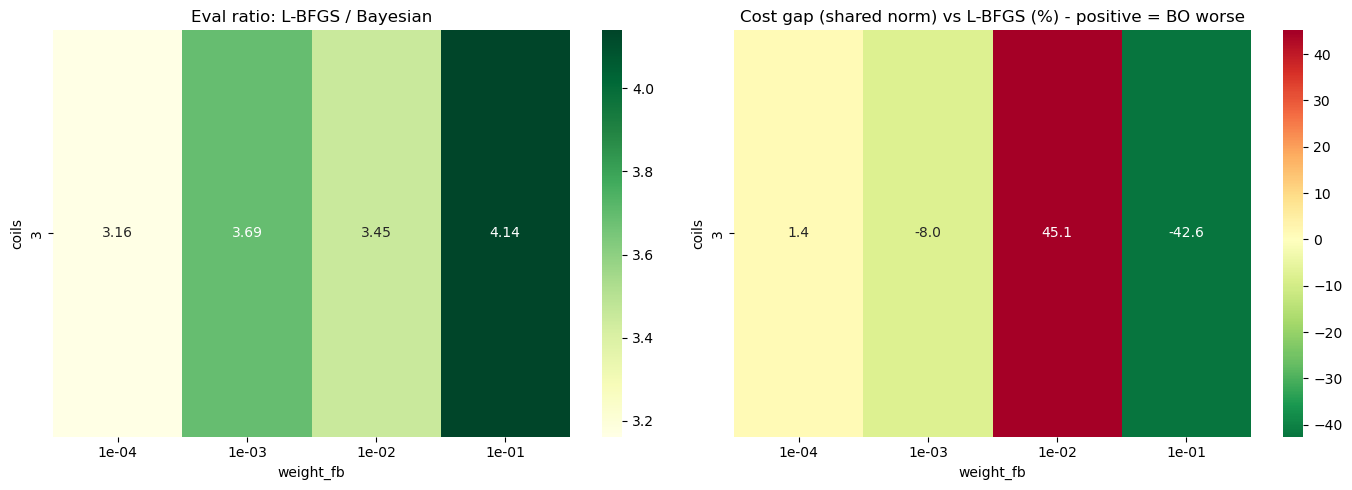

,1e-04,1e-03,1e-02,1e-01
num_coils,,,,
3,2,2,2,2


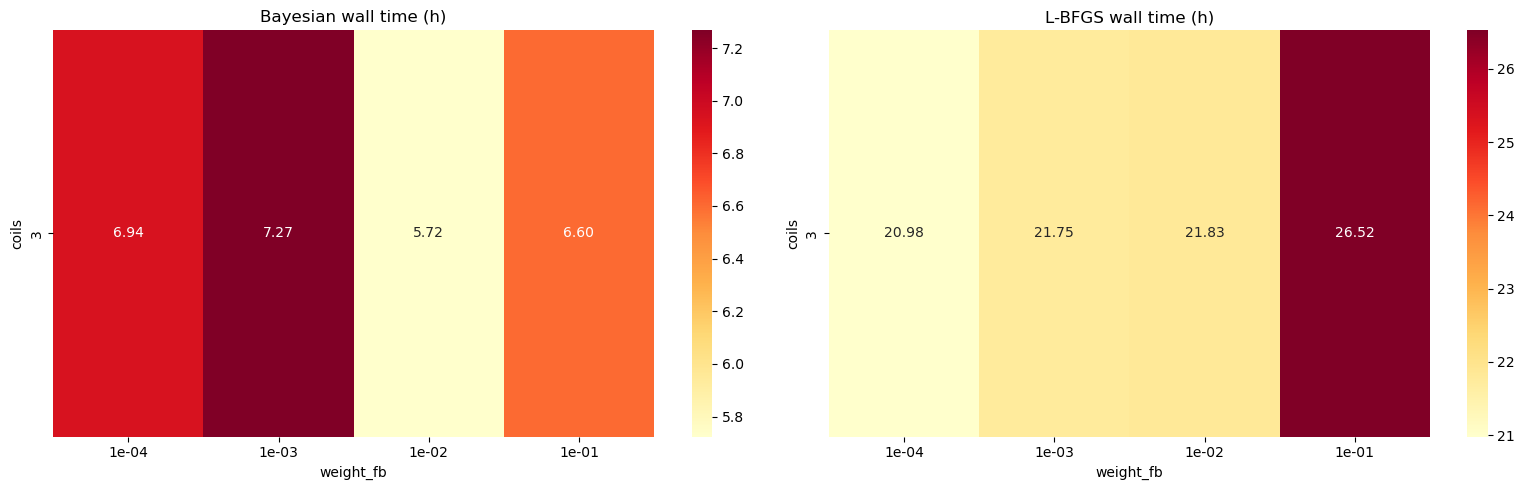

In [188]:
# bay vs lbfgs heatmaps across (coils x weight_fb) - mirrors bay_vs_lbfgs.ipynb style
best = df.sort_values('best_cost_shared').groupby(['num_coils', 'weight_fb', 'method'], sort=False).first().reset_index()

bay = best[best['method'] == 'Bayesian'].set_index(['num_coils', 'weight_fb'])
lbf = best[best['method'] != 'Bayesian'].set_index(['num_coils', 'weight_fb'])

cmp = pd.DataFrame(index=bay.index.union(lbf.index))
cmp['bayes_cost'] = bay['best_cost_shared']
cmp['lbfgs_cost'] = lbf['best_cost_shared']
cmp['bayes_evals'] = bay['n_evals']
cmp['lbfgs_evals'] = lbf['n_evals']
cmp['bayes_time_h'] = bay['elapsed_h']
cmp['lbfgs_time_h'] = lbf['elapsed_h']
cmp['cost_gap_lbfgs'] = (cmp['bayes_cost'] - cmp['lbfgs_cost']) / cmp['lbfgs_cost'] * 100
cmp['eval_ratio'] = cmp['lbfgs_evals'] / cmp['bayes_evals']
cmp = cmp.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title, fmt in [
    (axes[0], 'eval_ratio', 'Eval ratio: L-BFGS / Bayesian', '.2f'),
    (axes[1], 'cost_gap_lbfgs', 'Cost gap (shared norm) vs L-BFGS (%) - positive = BO worse', '.1f'),
]:
    pivot = cmp.pivot_table(index='num_coils', columns='weight_fb', values=col)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot.columns = [f'{c:.0e}' for c in pivot.columns]
    cmap = 'YlGn' if col == 'eval_ratio' else 'RdYlGn_r'
    center = None if col == 'eval_ratio' else 0
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax, center=center)
    ax.set_title(title)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('coils')
plt.tight_layout()
plt.show()

# run counts
counts = df.groupby(['num_coils', 'weight_fb']).size().reset_index(name='n_runs')
pivot = counts.pivot(index='num_coils', columns='weight_fb', values='n_runs').fillna(0).astype(int)
pivot.columns = [f'{c:.0e}' for c in pivot.columns]
display(pivot)

# timing heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, mcol, title in [
    (axes[0], 'bayes_time_h', 'Bayesian wall time (h)'),
    (axes[1], 'lbfgs_time_h', 'L-BFGS wall time (h)'),
]:
    pivot = cmp.pivot_table(index='num_coils', columns='weight_fb', values=mcol)
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)
    pivot.columns = [f'{c:.0e}' for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('weight_fb')
    ax.set_ylabel('coils')
plt.tight_layout()
plt.show()

per-refinement breakdown:


,num_coils,weight_fb,refinement,best_gp,best_after_ref,step_improve_pct,cumulative_improve_pct,n_evals_in_ref
0,3,1.0000e-01,1,3.9338e-01,3.9338e-01,0.0000e+00,0.0000e+00,140
1,3,1.0000e-01,2,3.9338e-01,3.9338e-01,0.0000e+00,0.0000e+00,161
2,3,1.0000e-01,3,3.9338e-01,3.9338e-01,0.0000e+00,0.0000e+00,147
3,3,1.0000e-02,1,9.0385e-01,9.0385e-01,0.0000e+00,0.0000e+00,119
4,3,1.0000e-02,2,9.0385e-01,8.1188e-01,1.0175e+01,1.0175e+01,140
5,3,1.0000e-02,3,9.0385e-01,8.1188e-01,0.0000e+00,1.0175e+01,133
6,3,1.0000e-03,1,9.0385e-01,9.0385e-01,0.0000e+00,0.0000e+00,140
7,3,1.0000e-03,2,9.0385e-01,9.0385e-01,0.0000e+00,0.0000e+00,112
8,3,1.0000e-03,3,9.0385e-01,9.0385e-01,0.0000e+00,0.0000e+00,161
9,3,1.0000e-04,1,7.6914e-01,7.6914e-01,0.0000e+00,0.0000e+00,140


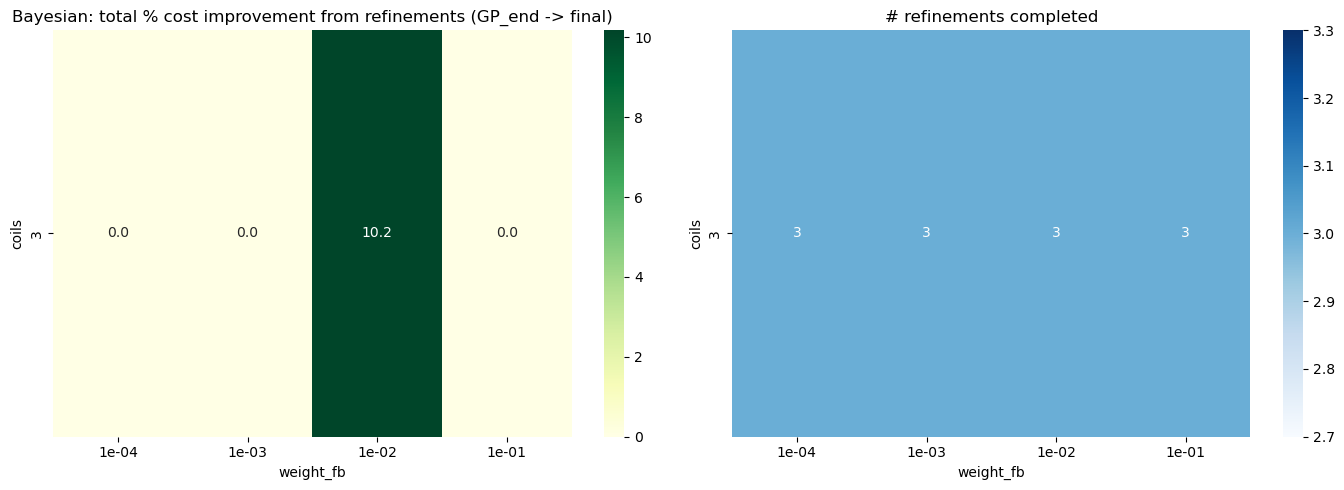

In [190]:
# bayesian refinement improvement: % cost reduction from end of GP phase to end of each refinement
ref_rows = []
for r in runs:
    if r['method'] != 'Bayesian':
        continue
    d = r['data']
    total = np.array(d['cost_history'], dtype=float)
    n_bay = d.get('n_bayesian_evals', 0)
    ref_evals = d.get('refinement_evals', []) or []
    if n_bay == 0 or len(total) <= n_bay:
        continue
    best_gp = float(np.nanmin(total[:n_bay]))
    cum = n_bay
    cum_best = best_gp
    for i, re in enumerate(ref_evals):
        prev_best = cum_best
        cum += re
        cum_best = float(np.nanmin(total[:cum]))
        step_improve = (prev_best - cum_best) / prev_best * 100 if prev_best > 0 else float('nan')
        cumulative_improve = (best_gp - cum_best) / best_gp * 100 if best_gp > 0 else float('nan')
        ref_rows.append({
            'num_coils': r['num_coils'],
            'weight_fb': r['weight_fb'],
            'refinement': i + 1,
            'best_gp': best_gp,
            'best_after_ref': cum_best,
            'step_improve_pct': step_improve,
            'cumulative_improve_pct': cumulative_improve,
            'n_evals_in_ref': re,
        })

ref_df = pd.DataFrame(ref_rows)
print('per-refinement breakdown:')
display(ref_df)

# total improvement per (coils, weight_fb): last refinement
total_imp = ref_df.sort_values('refinement').groupby(['num_coils', 'weight_fb']).last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv_total = total_imp.pivot_table(index='num_coils', columns='weight_fb', values='cumulative_improve_pct')
piv_total = piv_total.reindex(sorted(piv_total.columns), axis=1)
piv_total.columns = [f'{c:.0e}' for c in piv_total.columns]
sns.heatmap(piv_total, annot=True, fmt='.1f', cmap='YlGn', ax=axes[0])
axes[0].set_title('Bayesian: total % cost improvement from refinements (GP_end -> final)')
axes[0].set_xlabel('weight_fb')
axes[0].set_ylabel('coils')

piv_n = ref_df.groupby(['num_coils', 'weight_fb'])['refinement'].max().reset_index().pivot_table(
    index='num_coils', columns='weight_fb', values='refinement')
piv_n = piv_n.reindex(sorted(piv_n.columns), axis=1)
piv_n.columns = [f'{c:.0e}' for c in piv_n.columns]
sns.heatmap(piv_n, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
axes[1].set_title('# refinements completed')
axes[1].set_xlabel('weight_fb')
axes[1].set_ylabel('coils')
plt.tight_layout()
plt.show()
